# MBTI Text Dataset - Exploratory Data Analysis

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from nltk.corpus import stopwords
import ssl
import certifi
import nltk

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
nltk.download("stopwords")

sns.set_theme(style="whitegrid")

[nltk_data] Downloading package stopwords to /Users/mac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Dataset Overview

In [2]:
DATA_PATH = "../../../datasets/mbti/data/mbti_1.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(8675, 2)

In [3]:
df.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   type    8675 non-null   str  
 1   posts   8675 non-null   str  
dtypes: str(2)
memory usage: 135.7 KB


In [6]:
df["type"].value_counts()

type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64

## 2. Feature Engineering

In [7]:
df["posts"] = df["posts"].astype(str)

df["word_count"] = df["posts"].apply(lambda x: len(x.split()))
df["char_count"] = df["posts"].apply(len)
df["num_posts"] = df["posts"].apply(lambda x: len(x.split("|||")))

df["I_E"] = df["type"].str[0]
df["N_S"] = df["type"].str[1]
df["T_F"] = df["type"].str[2]
df["J_P"] = df["type"].str[3]

## 3. Text Cleaning

In [8]:
STOP_WORDS = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = text.replace("|||", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

def remove_stopwords(text):
    return " ".join(
        [w for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    )

df["clean"] = df["posts"].apply(clean_text)
df["clean_ns"] = df["clean"].apply(remove_stopwords)

## 4. Category Distribution

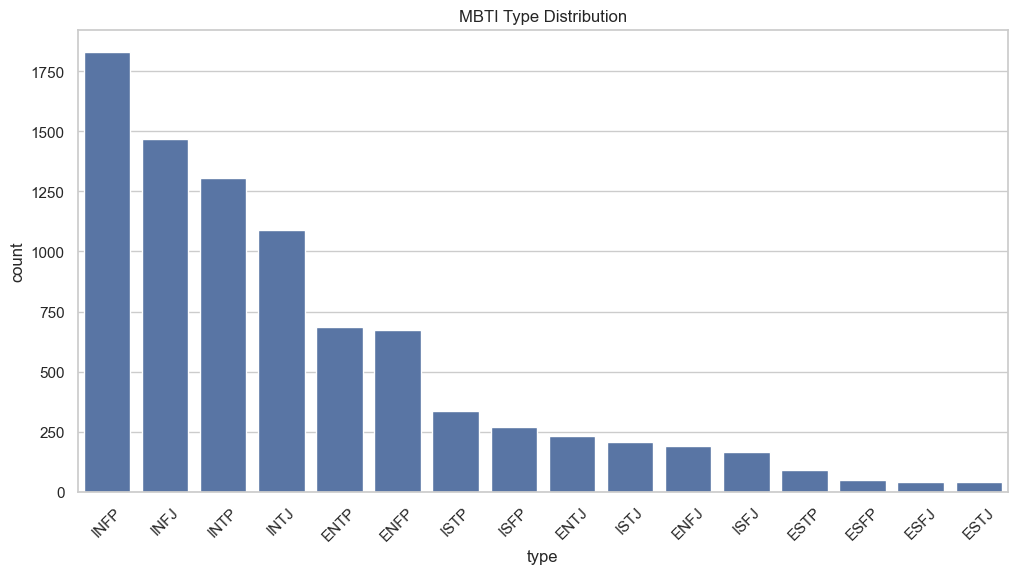

In [9]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.xticks(rotation=45)
plt.title("MBTI Type Distribution")
plt.show()

## 5. Trait Distribution

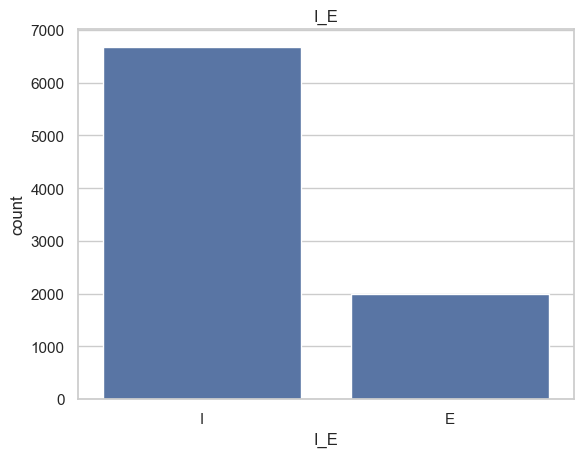

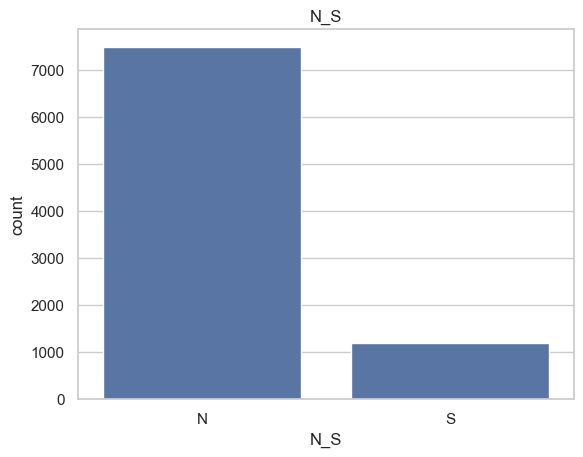

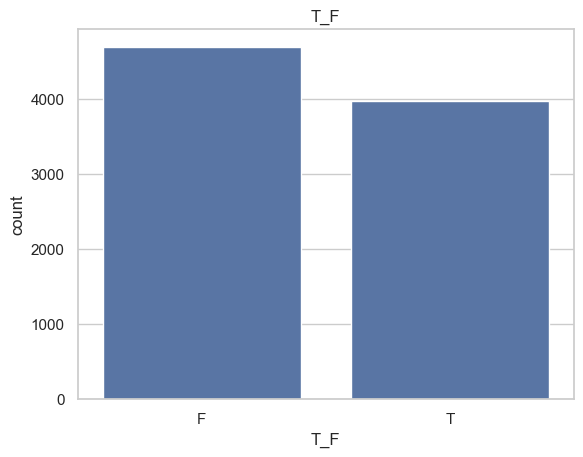

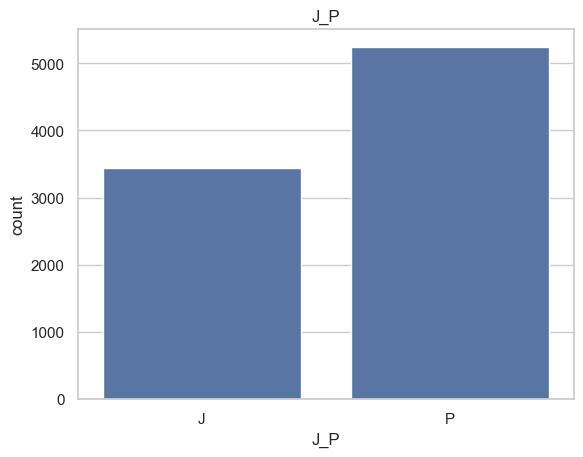

In [10]:
traits = ["I_E","N_S","T_F","J_P"]

for t in traits:
    plt.figure()
    sns.countplot(data=df, x=t)
    plt.title(t)
    plt.show()

## 6. Word Count Distribution

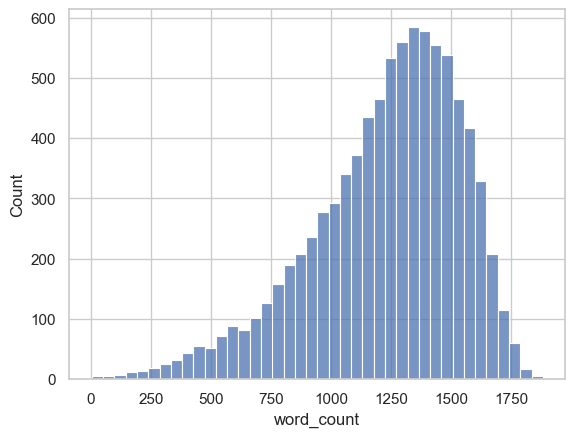

In [12]:
sns.histplot(df["word_count"], bins=40)
plt.show()

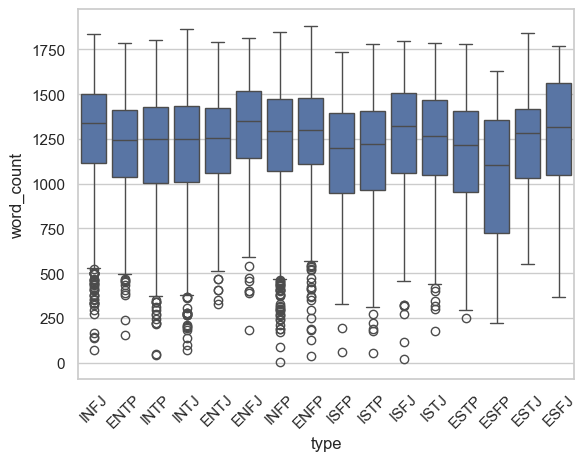

In [13]:
sns.boxplot(data=df, x="type", y="word_count")
plt.xticks(rotation=45)
plt.show()

## 7. Character Count Distribution

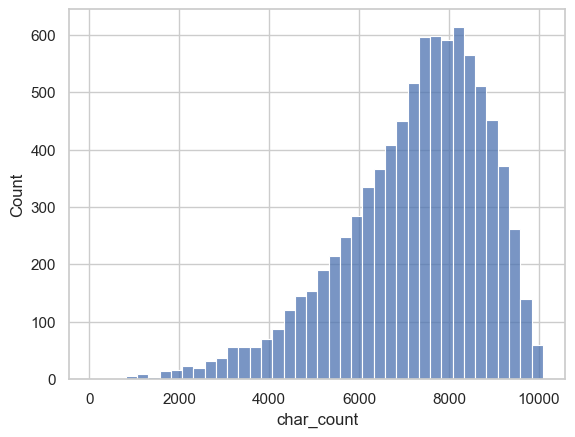

In [14]:
sns.histplot(df["char_count"], bins=40)
plt.show()

## 8. Number Of Posts Per User

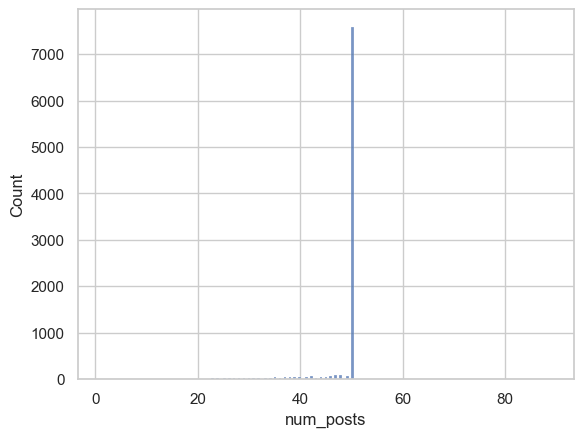

In [15]:
sns.histplot(df["num_posts"])
plt.show()

## 9. Stopword Analysis

In [17]:
tokens = " ".join(df["clean"]).split()
stop_tokens = [t for t in tokens if t in STOP_WORDS]
Counter(stop_tokens).most_common(20)

[('i', 632564),
 ('the', 309206),
 ('to', 305359),
 ('a', 246904),
 ('and', 244085),
 ('you', 187528),
 ('it', 186192),
 ('of', 185863),
 ('that', 163538),
 ('is', 140597),
 ('in', 131618),
 ('my', 126546),
 ('t', 111807),
 ('s', 110509),
 ('but', 95143),
 ('for', 92856),
 ('have', 84551),
 ('with', 83259),
 ('me', 83074),
 ('m', 77435)]

## 10. Vocabulary Richness

In [18]:
def vocab_stats(texts):
    tokens = " ".join(texts).split()
    return len(set(tokens)) / len(tokens)

for t, g in df.groupby("type"):
    print(t, vocab_stats(g["clean_ns"]))

ENFJ 0.11531426381436834
ENFP 0.06645150263918578
ENTJ 0.11642992705059012
ENTP 0.07114399258911513
ESFJ 0.21268962289903678
ESFP 0.2431223628691983
ESTJ 0.24663440387153543
ESTP 0.17858431922999798
INFJ 0.04451990338467329
INFP 0.0411957483281616
INTJ 0.05525517962516059
INTP 0.05116925551634997
ISFJ 0.12486582086958299
ISFP 0.10655317541682405
ISTJ 0.12081410483966394
ISTP 0.09950235628756735


## 11. Top Words Overall

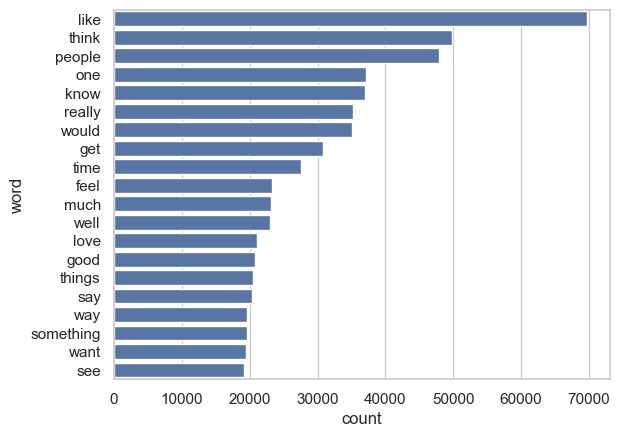

In [19]:
words = Counter(" ".join(df["clean_ns"]).split()).most_common(20)

w = pd.DataFrame(words, columns=["word","count"])

sns.barplot(data=w, x="count", y="word")
plt.show()

## 12. Top Words By Trait (I/E)

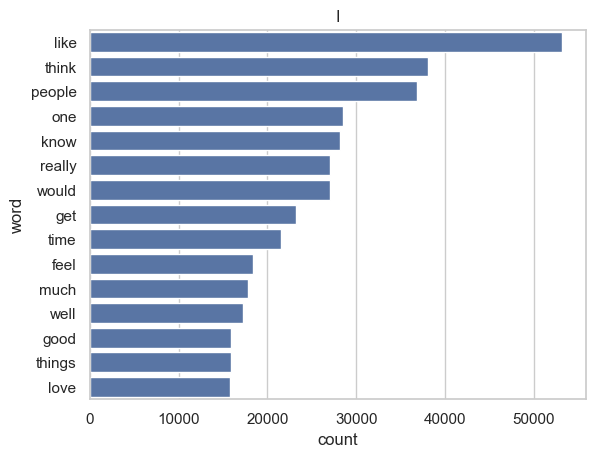

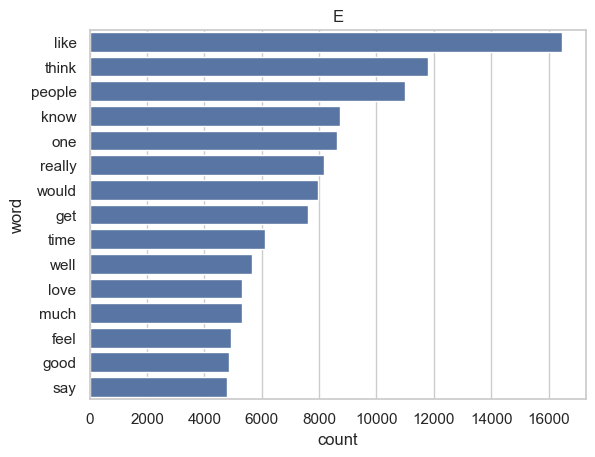

In [20]:
for t in ["I","E"]:
    words = Counter(
        " ".join(df[df["I_E"]==t]["clean_ns"]).split()
    ).most_common(15)

    w = pd.DataFrame(words, columns=["word","count"])

    sns.barplot(data=w, x="count", y="word")
    plt.title(t)
    plt.show()

## 13. TD-IDF By Trait

In [21]:
docs = df.groupby("I_E")["clean_ns"].apply(lambda x:" ".join(x))

vec = TfidfVectorizer(max_features=3000)

X = vec.fit_transform(docs)

terms = vec.get_feature_names_out()

In [22]:
for i,trait in enumerate(docs.index):

    arr = X[i].toarray()[0]

    idx = arr.argsort()[::-1][:10]

    print(trait,[terms[j] for j in idx])

E ['like', 'think', 'people', 'know', 'one', 'really', 'would', 'get', 'time', 'well']
I ['like', 'think', 'people', 'one', 'know', 'really', 'would', 'get', 'time', 'feel']


## 14. Bigram Analysis

In [23]:
vec = CountVectorizer(ngram_range=(2,2),max_features=20)

X = vec.fit_transform(df["clean"])

names = vec.get_feature_names_out()

counts = np.asarray(X.sum(axis=0)).flatten()

b = pd.DataFrame({"bigram":names,"count":counts})

b.sort_values("count",ascending=False)

,bigram,count
13,to be,27721
9,of the,24401
6,in the,23252
19,you re,15590
4,if you,13598
17,want to,13020
10,on the,12868
16,to the,12788
7,it is,12569
12,this is,11796


## 15. Similarity Matrix

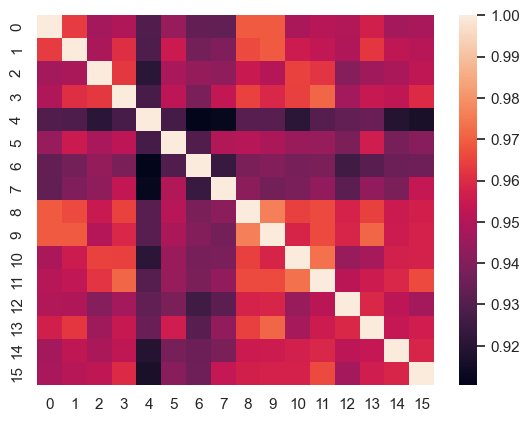

In [24]:
docs = df.groupby("type")["clean_ns"].apply(lambda x:" ".join(x))

vec = TfidfVectorizer(max_features=3000)

X = vec.fit_transform(docs)

sim = cosine_similarity(X)

sns.heatmap(sim)
plt.show()

## 16. Text Statistics

In [25]:
print("avg words",df["word_count"].mean())
print("avg chars",df["char_count"].mean())
print("avg posts",df["num_posts"].mean())

avg words 1226.2414985590779
avg chars 7234.98962536023
avg posts 48.74293948126801


## 17. Sample Posts

In [26]:
df.sample(3)[["type","posts"]]

,type,posts
478,ISTP,"I'm usually about average at games, and thats ..."
8308,ISTP,"'Wrong! I joined Y-Club, Academic Team and al..."
7714,INFJ,"'To my knowledge and experience, there are mor..."
